# YOLO Training and Comparative Analysis

Dataset used: **Road Sign Detection** from Kaggle  
KaggleHub slug: `andrewmvd/road-sign-detection`

This notebook:
1. Downloads the dataset from Kaggle using `kagglehub`.
2. Converts Pascal VOC XML annotations to YOLO format.
3. Splits the dataset into training and validation sets.
4. Trains YOLO from scratch.
5. Trains YOLO using transfer learning.
6. Runs inference on the same test image.
7. Compares bounding boxes, classification confidence, and validation metrics.

The notebook is saved without executed outputs.


## 1. Install Required Libraries

In [ ]:
!pip install ultralytics kagglehub -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.2 MB/s eta 0:00:00


## 2. Import Libraries

In [ ]:
import os
import random
import shutil
import xml.etree.ElementTree as ET
from pathlib import Path

import kagglehub
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## 3. Download Dataset from KaggleHub

In [ ]:
# Download Road Sign Detection dataset from Kaggle
path = kagglehub.dataset_download("andrewmvd/road-sign-detection")

print("Path to dataset files:", path)


Using Colab cache for faster access to the 'road-sign-detection' dataset.
Path to dataset files: /kaggle/input/road-sign-detection


## 4. Inspect Downloaded Dataset Structure

In [ ]:
for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for file in files[:5]:
        print(f"{indent}  {file}")


road-sign-detection/
  annotations/
    road732.xml
    road518.xml
    road717.xml
    road362.xml
    road492.xml
  images/
    road348.png
    road259.png
    road406.png
    road589.png
    road83.png


## 5. Find Images and XML Annotations

In [ ]:
dataset_path = Path(path)

image_files = []
xml_files = []

for file in dataset_path.rglob("*"):
    if file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
        image_files.append(file)
    elif file.suffix.lower() == ".xml":
        xml_files.append(file)

print("Number of images:", len(image_files))
print("Number of XML annotations:", len(xml_files))

print("\nExample image:", image_files[0] if image_files else "No image found")
print("Example XML:", xml_files[0] if xml_files else "No XML found")


Number of images: 877
Number of XML annotations: 877

Example image: /kaggle/input/road-sign-detection/images/road348.png
Example XML: /kaggle/input/road-sign-detection/annotations/road732.xml


## 6. Read Class Names from XML Files

In [ ]:
class_names = set()

for xml_file in xml_files:
    tree = ET.parse(xml_file)
    root = tree.getroot()

    for obj in root.findall("object"):
        name = obj.find("name").text.strip()
        class_names.add(name)

class_names = sorted(list(class_names))
class_to_id = {name: i for i, name in enumerate(class_names)}

print("Classes:", class_names)
print("Class to ID:", class_to_id)


Classes: ['crosswalk', 'speedlimit', 'stop', 'trafficlight']
Class to ID: {'crosswalk': 0, 'speedlimit': 1, 'stop': 2, 'trafficlight': 3}


## 7. Convert Pascal VOC XML to YOLO Format

In [ ]:
def convert_xml_to_yolo(xml_path, output_txt_path, class_to_id):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find("size")
    img_w = int(size.find("width").text)
    img_h = int(size.find("height").text)

    yolo_lines = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text.strip()
        class_id = class_to_id[class_name]

        bbox = obj.find("bndbox")
        xmin = float(bbox.find("xmin").text)
        ymin = float(bbox.find("ymin").text)
        xmax = float(bbox.find("xmax").text)
        ymax = float(bbox.find("ymax").text)

        x_center = ((xmin + xmax) / 2) / img_w
        y_center = ((ymin + ymax) / 2) / img_h
        width = (xmax - xmin) / img_w
        height = (ymax - ymin) / img_h

        yolo_lines.append(f"{class_id} {x_center} {y_center} {width} {height}")

    with open(output_txt_path, "w") as f:
        f.write("\n".join(yolo_lines))


## 8. Prepare YOLO Dataset Folder

In [ ]:
YOLO_DATASET = Path("/content/road_sign_yolo")

if YOLO_DATASET.exists():
    shutil.rmtree(YOLO_DATASET)

for split in ["train", "val"]:
    (YOLO_DATASET / "images" / split).mkdir(parents=True, exist_ok=True)
    (YOLO_DATASET / "labels" / split).mkdir(parents=True, exist_ok=True)

print("YOLO dataset folder created:", YOLO_DATASET)


YOLO dataset folder created: /content/road_sign_yolo


## 9. Match Images with XML Annotations and Split Data

In [ ]:
image_dict = {img.stem: img for img in image_files}
xml_dict = {xml.stem: xml for xml in xml_files}

matched_names = sorted(list(set(image_dict.keys()) & set(xml_dict.keys())))

print("Matched image/XML pairs:", len(matched_names))

random.seed(42)
random.shuffle(matched_names)

split_index = int(0.8 * len(matched_names))
train_names = matched_names[:split_index]
val_names = matched_names[split_index:]

print("Train samples:", len(train_names))
print("Validation samples:", len(val_names))


Matched image/XML pairs: 877
Train samples: 701
Validation samples: 176


## 10. Copy Images and Labels into YOLO Format

In [ ]:
def copy_split(names, split):
    for name in names:
        img_path = image_dict[name]
        xml_path = xml_dict[name]

        new_img_path = YOLO_DATASET / "images" / split / img_path.name
        new_label_path = YOLO_DATASET / "labels" / split / f"{name}.txt"

        shutil.copy(img_path, new_img_path)
        convert_xml_to_yolo(xml_path, new_label_path, class_to_id)

copy_split(train_names, "train")
copy_split(val_names, "val")

print("Dataset conversion finished.")
print("Train images:", len(list((YOLO_DATASET / "images" / "train").glob("*"))))
print("Val images:", len(list((YOLO_DATASET / "images" / "val").glob("*"))))


Dataset conversion finished.
Train images: 701
Val images: 176


## 11. Create YOLO data.yaml File

In [ ]:
DATA_YAML = YOLO_DATASET / "data.yaml"

yaml_content = f"""
path: {YOLO_DATASET}
train: images/train
val: images/val

nc: {len(class_names)}
names: {class_names}
"""

with open(DATA_YAML, "w") as f:
    f.write(yaml_content)

print("Created:", DATA_YAML)
print("\nYAML content:")
print(yaml_content)


Created: /content/road_sign_yolo/data.yaml

YAML content:

path: /content/road_sign_yolo
train: images/train
val: images/val

nc: 4
names: ['crosswalk', 'speedlimit', 'stop', 'trafficlight']



## 12. Train YOLO From Scratch

In [ ]:
scratch_model = YOLO("yolov8n.yaml")

scratch_model.train(
    data=str(DATA_YAML),
    epochs=10,
    imgsz=416,
    batch=8,
    device="cpu",
    name="road_sign_from_scratch",
    pretrained=False
)


Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/road_sign_yolo/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.yaml, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=road_sign_from_scratch, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e5c8c172d50>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

## 13. Train YOLO Using Transfer Learning

In [ ]:
transfer_model = YOLO("yolov8n.pt")

transfer_model.train(
    data=str(DATA_YAML),
    epochs=10,
    imgsz=416,
    batch=8,
    device="cpu",
    name="road_sign_transfer_learning"
)


Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/road_sign_yolo/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=road_sign_transfer_learning, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overl

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e5c97c9b3e0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

## 14. Load Best Trained Models

In [ ]:
scratch_best = YOLO("/content/runs/detect/road_sign_from_scratch/weights/best.pt")
transfer_best = YOLO("/content/runs/detect/road_sign_transfer_learning/weights/best.pt")


## 15. Select the Same Test Image

In [ ]:
test_images = list((YOLO_DATASET / "images" / "val").glob("*"))
TEST_IMAGE = str(test_images[0])
print("Test image used:", TEST_IMAGE)


Test image used: /content/road_sign_yolo/images/val/road340.png


## 16. Run Inference Using Both Models

In [ ]:
scratch_pred = scratch_best.predict(
    source=TEST_IMAGE,
    conf=0.25,
    save=True,
    name="scratch_prediction"
)

transfer_pred = transfer_best.predict(
    source=TEST_IMAGE,
    conf=0.25,
    save=True,
    name="transfer_prediction"
)



image 1/1 /content/road_sign_yolo/images/val/road340.png: 416x320 1 speedlimit, 98.6ms
Speed: 2.0ms preprocess, 98.6ms inference, 1.2ms postprocess per image at shape (1, 3, 416, 320)
Results saved to /content/runs/detect/scratch_prediction

image 1/1 /content/road_sign_yolo/images/val/road340.png: 416x320 1 speedlimit, 77.9ms
Speed: 1.7ms preprocess, 77.9ms inference, 1.0ms postprocess per image at shape (1, 3, 416, 320)
Results saved to /content/runs/detect/transfer_prediction


## 17. Display Both Predictions Side by Side

Scratch files: ['road340.jpg']
Transfer files: ['road340.jpg']


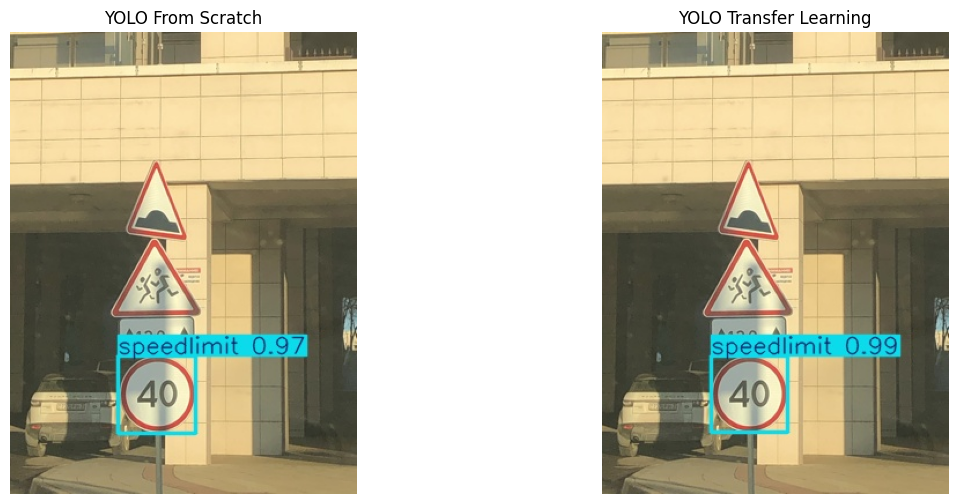

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

base = "/content/runs/detect"

scratch_folder = "/content/runs/detect/scratch_prediction"
transfer_folder = "/content/runs/detect/transfer_prediction"

print("Scratch files:", os.listdir(scratch_folder))
print("Transfer files:", os.listdir(transfer_folder))

scratch_files = [
    f for f in os.listdir(scratch_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

transfer_files = [
    f for f in os.listdir(transfer_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

scratch_img_path = os.path.join(scratch_folder, scratch_files[0])
transfer_img_path = os.path.join(transfer_folder, transfer_files[0])

scratch_img = Image.open(scratch_img_path)
transfer_img = Image.open(transfer_img_path)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(scratch_img)
plt.title("YOLO From Scratch")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(transfer_img)
plt.title("YOLO Transfer Learning")
plt.axis("off")

plt.show()

## 18. Print Bounding Box and Classification Details

In [ ]:
print("===== From Scratch Predictions =====")
for box in scratch_pred[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()
    print("Class:", scratch_best.names[cls_id], "| Confidence:", round(conf, 3), "| Box:", xyxy)

print("\n===== Transfer Learning Predictions =====")
for box in transfer_pred[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    xyxy = box.xyxy[0].tolist()
    print("Class:", transfer_best.names[cls_id], "| Confidence:", round(conf, 3), "| Box:", xyxy)


===== From Scratch Predictions =====
Class: speedlimit | Confidence: 0.972 | Box: [93.60765838623047, 280.8313903808594, 160.1399688720703, 347.65228271484375]

===== Transfer Learning Predictions =====
Class: speedlimit | Confidence: 0.989 | Box: [94.35618591308594, 280.87493896484375, 160.17262268066406, 346.235595703125]


## 19. Validate Both Models

In [ ]:
scratch_metrics = scratch_best.val(data=str(DATA_YAML), device="cpu")
transfer_metrics = transfer_best.val(data=str(DATA_YAML), device="cpu")


Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3216.7±589.5 MB/s, size: 260.7 KB)
val: Scanning /content/road_sign_yolo/labels/val.cache... 176 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 176/176 56.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 11/11 1.2s/it 13.2s
                   all        176        245      0.849      0.376      0.455      0.309
             crosswalk         30         32       0.86      0.281      0.403      0.248
            speedlimit        135        161      0.954      0.652      0.801      0.609
                  stop         21         21      0.581      0.571      0.561       0.36
          trafficlight         23         31          1          0     0.0554     0.0177
Speed: 0.6ms preprocess, 59.0ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/detec

## 20. Final Comparison

In [ ]:
print("===== Model Comparison =====")

print("\nFrom Scratch Model:")
print("mAP50:", scratch_metrics.box.map50)
print("mAP50-95:", scratch_metrics.box.map)
print("Precision:", scratch_metrics.box.mp)
print("Recall:", scratch_metrics.box.mr)

print("\nTransfer Learning Model:")
print("mAP50:", transfer_metrics.box.map50)
print("mAP50-95:", transfer_metrics.box.map)
print("Precision:", transfer_metrics.box.mp)
print("Recall:", transfer_metrics.box.mr)


===== Model Comparison =====

From Scratch Model:
mAP50: 0.45504093999909123
mAP50-95: 0.3087077060252682
Precision: 0.8488925448473156
Recall: 0.3762131211180124

Transfer Learning Model:
mAP50: 0.9028131908466558
mAP50-95: 0.7450232010875588
Precision: 0.9494883365916836
Recall: 0.8635658637551635


## 21. Explanation for Report

The two models differ mainly in their initialization. The from-scratch model starts with random weights, so it must learn all visual features directly from the road sign dataset. This includes low-level features such as edges and colors, mid-level features such as shapes, and high-level features such as road sign categories.

The transfer learning model starts from pretrained YOLO weights. These weights already contain useful visual knowledge learned from a large dataset. During training, the model adapts this previous knowledge to the road sign detection task. This usually gives better bounding boxes, higher confidence scores, and better classification performance, especially when the dataset is limited.
